In [1]:
import cv2
import torch
import os
import sys
sys.path.append(os.path.abspath('..'))
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from models.u_net import UNet
from models.load_model import load_model
from models.predict import predict
from utils.augmentation import get_val_transforms

In [2]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {DEVICE}')

device: cuda


In [7]:
model = load_model(model_path='C:/Users/Cerdas05/Skripshot/U-Net-Architecture/checkpoints (50 ep 25 mei 2026)/bothat/best_model.pth', device=DEVICE)

c:\Users\Cerdas05\Skripshot\U-Net-Architecture\models\load_model.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(model_path, map_location=device)


model has been loaded | Best Dice: 0.8772


In [9]:
from pathlib import Path
from tqdm import tqdm
import pandas as pd

IMG_DIR  = Path('C:\\Users\\Cerdas05\\Skripshot\\U-Net-Architecture\\processed\\2_bothat\\testing\\images\\')
MASK_DIR = Path('C:\\Users\\Cerdas05\\Skripshot\\U-Net-Architecture\\processed\\2_bothat\\testing\\masks\\')
SAVE_DIR = Path('C:\\Users\\Cerdas05\\Skripshot\\U-Net-Architecture\\predict\\bothat')

image_paths = sorted([p for p in IMG_DIR.iterdir() if p.suffix in ('.jpg', '.png', '.jpeg')])

all_metrics = []

for img_path in tqdm(image_paths, desc='Predicting'):
    stem      = img_path.stem                                          # e.g. ISIC_0012169
    mask_path = MASK_DIR / f'{stem}_segmentation.png'

    if not mask_path.exists():
        print(f'[SKIP] mask tidak ditemukan: {mask_path.name}')
        continue

    _, metrics = predict(
        model,
        img_path=str(img_path),
        mask_path=str(mask_path),
        save_path=str(SAVE_DIR),
        device=DEVICE,
    )
    metrics['image'] = img_path.name
    all_metrics.append(metrics)

df_metrics = pd.DataFrame(all_metrics).set_index('image')
print(f'\nSelesai: {len(df_metrics)} gambar diprediksi\n')
print(df_metrics.describe().loc[['mean', 'std', 'min', 'max']].to_string())

Predicting:   0%|          | 0/1000 [00:00<?, ?it/s]

Predicting: 100%|██████████| 1000/1000 [01:00<00:00, 16.62it/s]


Selesai: 1000 gambar diprediksi

              dice           iou  accuracy     precision        recall  specificity
mean  7.634335e-01  6.600373e-01  0.878951  7.867226e-01  8.387106e-01     0.926857
std   2.263553e-01  2.369503e-01  0.150810  1.983901e-01  2.641399e-01     0.094651
min   1.800828e-11  1.800828e-11  0.131912  6.657789e-10  1.800828e-11     0.184023
max   9.782305e-01  9.573886e-01  0.997696  1.000000e+00  1.000000e+00     1.000000


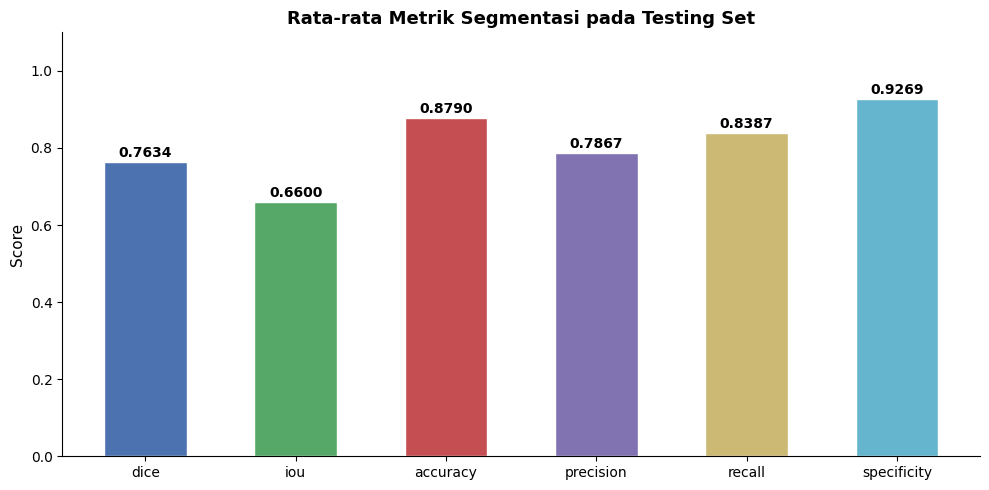


Ringkasan metrik per gambar:


,dice,iou,accuracy,precision,recall,specificity
image,,,,,,
ISIC_0012169.jpg,0.6495,0.4810,0.8570,0.5550,0.7829,0.8721
ISIC_0012236.jpg,0.7064,0.5460,0.9709,0.5460,1.0000,0.9698
ISIC_0012292.jpg,0.6056,0.4343,0.9891,0.4343,1.0000,0.9890
ISIC_0012302.jpg,0.8174,0.6911,0.9825,0.6911,1.0000,0.9818
ISIC_0012337.jpg,0.8324,0.7129,0.9925,0.7129,1.0000,0.9924
ISIC_0012373.jpg,0.6168,0.4459,0.8042,0.4459,1.0000,0.7675
ISIC_0012405.jpg,0.8914,0.8040,0.9814,0.8053,0.9980,0.9800
ISIC_0012418.jpg,0.2513,0.1437,0.8367,0.1437,1.0000,0.8321
ISIC_0012456.jpg,0.2078,0.1160,0.7891,0.1160,1.0000,0.7831


In [10]:
metric_cols = ['dice', 'iou', 'accuracy', 'precision', 'recall', 'specificity']
means = df_metrics[metric_cols].mean()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974', '#64B5CD']
bars = ax.bar(metric_cols, means.values, color=colors, width=0.55, edgecolor='white')

for bar, val in zip(bars, means.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Rata-rata Metrik Segmentasi pada Testing Set', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)

ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('\nRingkasan metrik per gambar:')
display(df_metrics[metric_cols].style.background_gradient(cmap='RdYlGn', axis=0).format('{:.4f}'))

In [ ]:
from utils.visualize import _to_binary_mask, _make_error_map
from matplotlib.patches import Patch

# Ganti index atau nama file sesuai sample yang ingin divisualisasikan
sample_name = image_paths[0].name
stem        = Path(sample_name).stem

img_path_viz  = IMG_DIR  / sample_name
mask_path_viz = MASK_DIR / f'{stem}_segmentation.png'
pred_path_viz = SAVE_DIR / sample_name

img_raw  = cv2.imread(str(img_path_viz))
gt_raw   = cv2.imread(str(mask_path_viz), cv2.IMREAD_GRAYSCALE)
pred_raw = cv2.imread(str(pred_path_viz), cv2.IMREAD_GRAYSCALE)

img       = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
gt_mask   = (gt_raw > 127).astype(np.uint8)
pred_mask = (pred_raw > 127).astype(np.uint8)

# Hitung metrik
tp   = np.sum((gt_mask == 1) & (pred_mask == 1))
fp   = np.sum((gt_mask == 0) & (pred_mask == 1))
fn   = np.sum((gt_mask == 1) & (pred_mask == 0))
dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
iou  = tp / (tp + fp + fn + 1e-8)

# Buat overlay error map pada gambar asli
error_map = _make_error_map(gt_mask, pred_mask)
region    = (gt_mask == 1) | (pred_mask == 1)
alpha     = 0.55
overlay   = img.copy().astype(np.float32)
overlay[region] = overlay[region] * (1 - alpha) + error_map[region].astype(np.float32) * alpha
overlay   = np.clip(overlay, 0, 255).astype(np.uint8)

# Plot
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('Hasil Segmentasi U-Net — Per Sample', fontsize=14, fontweight='bold')

axes[0].imshow(img)
axes[0].set_title('Citra Input', fontweight='bold')
axes[0].axis('off')

axes[1].imshow(gt_mask, cmap='gray')
axes[1].set_title('Ground Truth', fontweight='bold')
axes[1].axis('off')

axes[2].imshow(pred_mask, cmap='gray')
axes[2].set_title(f'Prediksi Model\nDice={dice*100:.2f}%  IoU={iou*100:.2f}%', fontweight='bold')
axes[2].axis('off')

axes[3].imshow(overlay)
axes[3].set_title('Overlay (TP/FP/FN)', fontweight='bold')
axes[3].axis('off')

legend = [
    Patch(facecolor='#00C800', label='TP (benar)'),
    Patch(facecolor='#DC0000', label='FP (over-seg)'),
    Patch(facecolor='#0050DC', label='FN (terlewat)'),
]
fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

In [ ]:
from utils.visualize import _make_error_map
from matplotlib.patches import Patch

COMPARE_DIR = Path('C:\\Users\\Cerdas05\\Skripshot\\U-Net-Architecture\\comparison\\bothat')
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

for img_path in tqdm(image_paths, desc='Saving comparisons'):
    stem          = img_path.stem
    mask_path_viz = MASK_DIR / f'{stem}_segmentation.png'
    pred_path_viz = SAVE_DIR / img_path.name

    if not mask_path_viz.exists() or not pred_path_viz.exists():
        continue

    img_raw  = cv2.imread(str(img_path))
    gt_raw   = cv2.imread(str(mask_path_viz), cv2.IMREAD_GRAYSCALE)
    pred_raw = cv2.imread(str(pred_path_viz), cv2.IMREAD_GRAYSCALE)

    if img_raw is None or gt_raw is None or pred_raw is None:
        continue

    img       = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
    gt_mask   = (gt_raw > 127).astype(np.uint8)
    pred_mask = (pred_raw > 127).astype(np.uint8)

    tp   = np.sum((gt_mask == 1) & (pred_mask == 1))
    fp   = np.sum((gt_mask == 0) & (pred_mask == 1))
    fn   = np.sum((gt_mask == 1) & (pred_mask == 0))
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)
    iou  = tp / (tp + fp + fn + 1e-8)

    error_map = _make_error_map(gt_mask, pred_mask)
    region    = (gt_mask == 1) | (pred_mask == 1)
    alpha     = 0.55
    overlay   = img.copy().astype(np.float32)
    overlay[region] = overlay[region] * (1 - alpha) + error_map[region].astype(np.float32) * alpha
    overlay   = np.clip(overlay, 0, 255).astype(np.uint8)

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))
    fig.suptitle('Hasil Segmentasi U-Net — Per Sample', fontsize=14, fontweight='bold')

    axes[0].imshow(img);                  axes[0].set_title('Citra Input', fontweight='bold');   axes[0].axis('off')
    axes[1].imshow(gt_mask, cmap='gray'); axes[1].set_title('Ground Truth', fontweight='bold');  axes[1].axis('off')
    axes[2].imshow(pred_mask, cmap='gray')
    axes[2].set_title(f'Prediksi Model\nDice={dice*100:.2f}%  IoU={iou*100:.2f}%', fontweight='bold')
    axes[2].axis('off')
    axes[3].imshow(overlay);             axes[3].set_title('Overlay (TP/FP/FN)', fontweight='bold'); axes[3].axis('off')

    legend = [
        Patch(facecolor='#00C800', label='TP (benar)'),
        Patch(facecolor='#DC0000', label='FP (over-seg)'),
        Patch(facecolor='#0050DC', label='FN (terlewat)'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9,
               framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    save_name = COMPARE_DIR / f'{stem}_comparison.png'
    fig.savefig(str(save_name), bbox_inches='tight', dpi=120)
    plt.close(fig)

print(f'Selesai: {len(list(COMPARE_DIR.iterdir()))} gambar tersimpan di {COMPARE_DIR}')

Saving comparisons: 100%|██████████| 1000/1000 [15:52<00:00,  1.05it/s]

Selesai: 1000 gambar tersimpan di C:\Users\Cerdas05\Skripshot\U-Net-Architecture\predict\comparison
